# CrunchTope + rhea worked example — an isotope system through a log K recomputation

The two database features that need care together. `database_isotopes` builds an isotope system;
`database_logk` recomputes the log K columns. Used at once, they interact in a way that is easy to
miss and expensive to miss.

**The problem.** `add_isotope` copies log Ks *unchanged*, deliberately, so that nothing it does
imposes a fractionation: an isotopologue and its parent are identical by construction, and any
fractionation in the model is one the modeller put there. pyGCC holds no isotopologues — it can
compute `CaSO4(aq)` and has never heard of `CaS34O4(aq)` — so a recomputation moves one side of every
labelled pair and leaves the other. The gap that opens up **is** an equilibrium fractionation, in a
database whose author imposed none, and nothing about the output says so.

**What Omphalos does.** It records which rows carry identical log K columns before rewriting
anything; any group where pyGCC updated some members and not others has been split by that call, and
is rejoined from the recomputed member. The sweep log says how many rows moved. This notebook checks
it, and quantifies what the invented fractionation would have been.

**The system.** A gypsum column at 25 °C, sulfur carried as `SO4--` and `S34O4--`, taken from 150 to
1000 bar. Neither the deck's database nor the shipped `datacom.dbs` contains any S34: the whole
system is built from the config before each run.

## 1. The experiment as written down

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

style_path = Path.home() / 'Python' / 'mpl_styles' / 'publication.mplstyle'
if style_path.exists():
    plt.style.use(str(style_path))

HERE = Path.cwd()

# The repository root, for omphalos.database. Found by walking up for a marker rather than by
# counting directories, so the example still works if this folder is moved or copied.
root = next((parent for parent in [HERE, *HERE.parents]
             if (parent / 'omphalos' / 'database.py').exists()), None)
if root is None:
    raise RuntimeError('Run this notebook from inside an Omphalos checkout: omphalos/database.py '
                       'was not found in any parent directory.')
sys.path.insert(0, str(root))

from omphalos.database import Database

CONFIG = HERE / 'isotope_pressure_series.yaml'
RESULTS = HERE / 'results.nc'
CONDITIONS = HERE / 'conditions.nc'

print(CONFIG.read_text())

# Omphalos / CrunchTope example — an isotope system and a log K recomputation
# together, which is the one combination that needs care.
#
# A gypsum column carries sulfur as SO4-- and S34O4--. Neither the deck's database
# nor the deck's chemistry ships with S34: database_isotopes builds the whole
# system first, and database_logk then recomputes the log K columns at a different
# pressure for each run.
#
# THE INTERACTION
# ---------------
# pyGCC holds no isotopologues. It can recompute CaSO4(aq) and has never heard of
# CaS34O4(aq), so a recomputation moves one side of every labelled pair and leaves
# the other -- and the gap that opens between them is an equilibrium fractionation
# the database never had. add_isotope copies log Ks unchanged precisely so that
# nothing it does imposes a fractionation, and a recomputation would undo that.
#
# Omphalos copies each parent's new column onto its copy, reporting how many rows
# it moved. The notebook checks the pair is still identical at 

Two blocks, and the order matters. `database_isotopes` runs first, because a recomputation can only
hold a pair together if the pair is already there. `names` is needed because `Gypsum` is a trivial
name — the formula rule needs a capital S to label and there is none, so it reports it rather than
guessing.

That same fact is why the pairing cannot be recovered from names later: `Gypsum34` carries no element
symbol before its digits. The mapping used to hold the pair together is the one recorded when the
system was built.

## 2. Run the sweep — in the shell, before opening this notebook

```bash
rhea isotope_pressure_series.yaml local --compile-inputs      # five runs, about a minute
```

The sweep log reports the rejoining once per run:

```
3 isotopologue row(s) copied back from the parent pyGCC recomputed and they cannot be,
so no fractionation is invented: ['secondary_species/CaS34O4(aq)',
'secondary_species/HS34O4-', 'secondary_species/NaS34O4-']
```

In [2]:
missing = [f.name for f in (RESULTS, CONDITIONS) if not f.exists()]
if missing:
    raise FileNotFoundError(f'{", ".join(missing)} not found — run the command above first.')

pressure = xr.open_dataset(CONDITIONS, group='database_logk')['pressure']
totcon = xr.open_dataset(RESULTS, group='totcon').squeeze(drop=True)

P = pressure.sel(file_num=totcon['file_num']).values
runs = totcon['file_num'].values
print(f'pressures recorded: {P} bar')

pressures recorded: [ 150.  250.  400.  600. 1000.] bar


## 3. Did the pairs stay together?

The check that matters. Read each pair straight back out of the database the run used.

In [3]:
PAIRS = [('secondary_species', 'CaSO4(aq)', 'CaS34O4(aq)'),
         ('secondary_species', 'HSO4-', 'HS34O4-'),
         ('secondary_species', 'NaSO4-', 'NaS34O4-'),
         ('minerals', 'Gypsum', 'Gypsum34')]

databases = {run: Database(str(HERE / f'run{run}' / 'datacom.dbs')) for run in runs}

gaps = {}
for section, parent, child in PAIRS:
    row = []
    for run in runs:
        a = [float(v) for v in databases[run].value(section, parent, 'log_k')]
        b = [float(v) for v in databases[run].value(section, child, 'log_k')]
        row.append(max(abs(x - y) for x, y in zip(a, b)))
    gaps[child] = row

pd.DataFrame(gaps, index=pd.Index(P, name='pressure (bar)')).T

pressure (bar),150.0,250.0,400.0,600.0,1000.0
CaS34O4(aq),0.0,0.0,0.0,0.0,0.0
HS34O4-,0.0,0.0,0.0,0.0,0.0
NaS34O4-,0.0,0.0,0.0,0.0,0.0
Gypsum34,0.0,0.0,0.0,0.0,0.0


Zero everywhere. Now the counterfactual: how large would the fractionation have been?

It is exactly the parent's own pressure shift, because the copy would have stayed where it started.
So it can be read off the parents alone, with no need to reconstruct the broken behaviour.

In [4]:
shifts = {}
for section, parent, child in PAIRS:
    at_lowest = np.array([float(v) for v in databases[runs[0]].value(section, parent, 'log_k')])
    row = []
    for run in runs:
        here = np.array([float(v) for v in databases[run].value(section, parent, 'log_k')])
        row.append(float(np.max(np.abs(here - at_lowest))))
    shifts[parent] = row

table = pd.DataFrame(shifts, index=pd.Index(P, name='pressure (bar)')).T
print('the fractionation that would have been invented, in log K units:')
table

the fractionation that would have been invented, in log K units:


pressure (bar),150.0,250.0,400.0,600.0,1000.0
CaSO4(aq),0.0,0.2049,0.4571,0.7132,1.0422
HSO4-,0.0,0.1094,0.2468,0.3921,0.5969
NaSO4-,0.0,0.1145,0.2567,0.4040,0.6012
Gypsum,0.0,0.0000,0.0000,0.0000,0.0000


`Gypsum` sits at zero because pyGCC has no entry for it, so it was never recomputed and never at
risk. The three aqueous pairs are the live ones, and `CaSO4(aq)` reaches about 0.1 log units by
1000 bar — a 26% shift in an equilibrium constant, which for isotope work is enormous. On a database
whose parents pyGCC knows better, it is larger still: `SukindaCr53.dbs` separates `H2S(aq)` from
`H2S34(aq)` by 0.33 log units at 500 bar.

## 4. And in the model

Sulfur compositions are reported as δ³⁴S against VCDT, where (³⁴S/³²S)$_{VCDT}$ = 0.0441626
(Ding et al., 2001):

$$\delta^{34}\mathrm{S} = \left(\frac{(^{34}\mathrm{S}/^{32}\mathrm{S})_{\mathrm{sample}}}
{(^{34}\mathrm{S}/^{32}\mathrm{S})_{\mathrm{VCDT}}} - 1\right) \times 1000$$

Identical log Ks mean no equilibrium fractionation, and this deck imposes no kinetic one, so the
fluid should carry the composition it is given — everywhere in the column, at every pressure.

In [5]:
VCDT = 0.0441626      # 34S/32S, Ding et al. (2001)


def delta34S(ratio):
    return 1e3 * (ratio / VCDT - 1.0)


S32 = totcon['SO4--']
S34 = totcon['S34O4--']
delta = delta34S((S34 / S32).isel(time=1))     # the 5 yr slice
x = totcon['X'].values

print(f'the water and the gypsum, as specified: {delta34S(4.21e-8 / 9.58e-7):+8.3f} per mil')
print()
for i, p in enumerate(P):
    row = delta.isel(file_num=i).values
    print(f'{p:7.0f} bar   inflow end {row[0]:+8.3f}   outflow {row[-1]:+8.3f}   '
          f'range along the column {row.max() - row.min():.2e}')

print()
spread = float(delta[:, -1].max() - delta[:, -1].min())
print(f'spread of the outflow across the whole pressure series: {spread:.2e} per mil')

the water and the gypsum, as specified:   -4.911 per mil

    150 bar   inflow end   -4.911   outflow   -4.911   range along the column 4.80e-06
    250 bar   inflow end   -4.911   outflow   -4.911   range along the column 3.70e-06
    400 bar   inflow end   -4.911   outflow   -4.911   range along the column 1.70e-06
    600 bar   inflow end   -4.911   outflow   -4.911   range along the column 5.84e-06
   1000 bar   inflow end   -4.911   outflow   -4.911   range along the column 2.64e-06

spread of the outflow across the whole pressure series: 4.94e-06 per mil


Flat to five decimal places down the column, and flat to 5 × 10⁻⁶ ‰ across a sevenfold change in
pressure. That is the invariant the rejoining protects.

**The scale of what it protects against.** A pair separated by Δ log K fractionates by
(10^Δ − 1) × 1000 ‰ in any equilibrium the pair takes part in. `CaSO4(aq)` moves 0.1006 log units
between 150 and 1000 bar, so an unprotected recomputation would put roughly **260 ‰** of invented
fractionation into this system — against a natural range for sulfate of a few tens of per mil. On a
database whose parents pyGCC knows better it is worse: `SukindaCr53.dbs` separates `H2S(aq)` from
`H2S34(aq)` by 0.33 log units at 500 bar, which is over 1000 ‰.

## 5. The figure

**A** — the pair gap at every pressure, which the rejoining holds at zero, against the log K shift
that would otherwise have opened up between parent and copy.

**B** — δ³⁴S down the column, one line per pressure, against the composition the system was given.
Five coincident flat lines is the result.

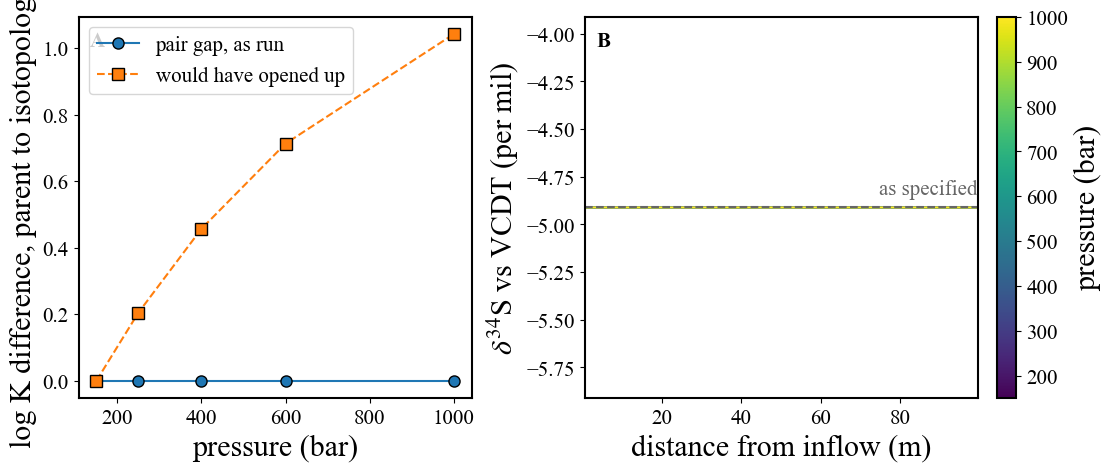

In [6]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)

axA.plot(P, [max(gaps[child][i] for child in gaps) for i in range(len(P))],
         marker='o', label='pair gap, as run')
axA.plot(P, table.loc['CaSO4(aq)'].values, marker='s', linestyle='--',
         label='would have opened up')
axA.set_xlabel('pressure (bar)')
axA.set_ylabel('log K difference, parent to isotopologue')
axA.legend(loc='upper left')
axA.text(0.03, 0.96, 'A', transform=axA.transAxes, fontweight='bold', va='top')

norm = Normalize(P.min(), P.max())
cmap = plt.get_cmap('viridis')
given = delta34S(4.21e-8 / 9.58e-7)

for i, p in enumerate(P):
    axB.plot(x, delta.isel(file_num=i).values, color=cmap(norm(p)))
axB.axhline(given, linestyle='--', color='0.4')
axB.annotate('as specified', (x.max(), given), xytext=(0, 6), textcoords='offset points',
             ha='right', va='bottom', color='0.4')
axB.set_xlim(x.min(), x.max())
axB.set_ylim(given - 1.0, given + 1.0)
axB.set_xlabel('distance from inflow (m)')
axB.set_ylabel(r'$\delta^{34}$S vs VCDT (per mil)')
axB.text(0.03, 0.96, 'B', transform=axB.transAxes, fontweight='bold', va='top')
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axB)
cbar.set_label('pressure (bar)')

fig.savefig(HERE / 'isotope_pressure_series.png', dpi=200)

## 6. Two things to take away

**Declare your isotopes if you are going to recompute.** The pairing that holds a copy to its parent
comes from what `database_isotopes` recorded when it built the system. A database that merely *ships*
with isotopologues, recomputed with no `database_isotopes` block, is protected only where the names
give the pairing away — `H2S34(aq)` yes, `Gypsum34` no, since no rule recovers `Gypsum` from a name
ending in a lowercase letter and digits. In that case the split is reported rather than repaired:

```
WARNING: n row(s) were identical to a recomputed row before this call and are not now,
and their names do not look like an isotope label, so they were left alone.
```

Take that warning seriously. It is the one case where the invariant can break, and it names the rows.

**The deck has to link the pairs too.** Building the species is half of it; CrunchTope needs an
`ISOTOPES` block with a line for each pair, minerals included:

```
ISOTOPES
primary  S34O4--   SO4--    0.0441626
mineral  Gypsum34  Gypsum   none
END
```

Leave the `mineral` line out and `Gypsum` and `Gypsum34` are independent phases, each driving its own
ion activity product to the same K — the fluid then degenerates to ³⁴SO₄ = SO₄, about +21,600 ‰,
whatever the amounts present. That is a deck error rather than a database one, and it looks exactly
like a thermodynamic problem, so it is worth knowing about. `-associate` in the `MINERALS` block is
not the mechanism; it ties a rate law to another mineral's volume fraction.